<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_DECOMPOSI%C3%87%C3%83O.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BIBLIOTECAS

In [1]:
from dateutil.parser import parse
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

print('✅ Bibliotecas carregadas!')

✅ Bibliotecas carregadas!


1. Load data Set

In [19]:
# dataset source: https://github.com/rouseguy
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
df.head()

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


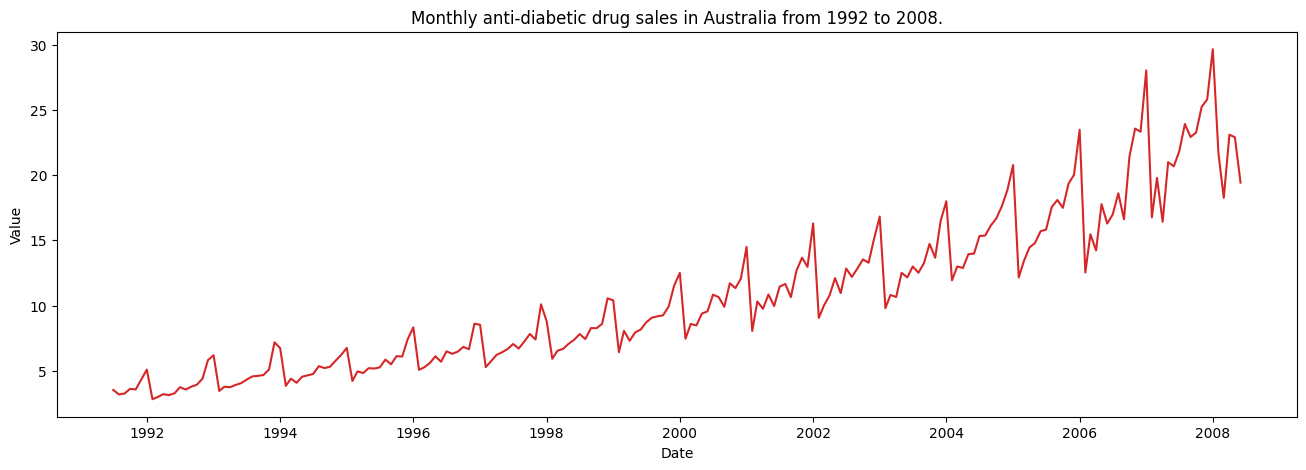

In [21]:
################################
#1. Visualizando a série temporal
################################

def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df, x=df.index, y=df.value, title='Monthly anti-diabetic drug sales in Australia from 1992 to 2008.')

Esse gráfico mostra tendência de sazonalidade, logo não seria ruído branco e não é estacionária (não tem média constante).

In [24]:
###############################################
# Outros grafico interessante para analisar a serie por período
# Boxplot of Month-wise (Seasonal) and Year-wise (trend) Distribution
###############################################

df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')
df.reset_index(inplace=True)

df.head()

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


In [30]:
# Prepare data
df['year'] = [d.year for d in df.date]
df['month'] = [d.strftime('%b') for d in df.date]
years = df['year'].unique()
months = df['month'].unique()
df.head()

,date,value,year,month
0,1991-07-01,3.526591,1991,Jul
1,1991-08-01,3.180891,1991,Aug
2,1991-09-01,3.252221,1991,Sep
3,1991-10-01,3.611003,1991,Oct
4,1991-11-01,3.565869,1991,Nov


In [31]:
years

array([1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008])

In [32]:
months

array(['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar',
       'Apr', 'May', 'Jun'], dtype=object)

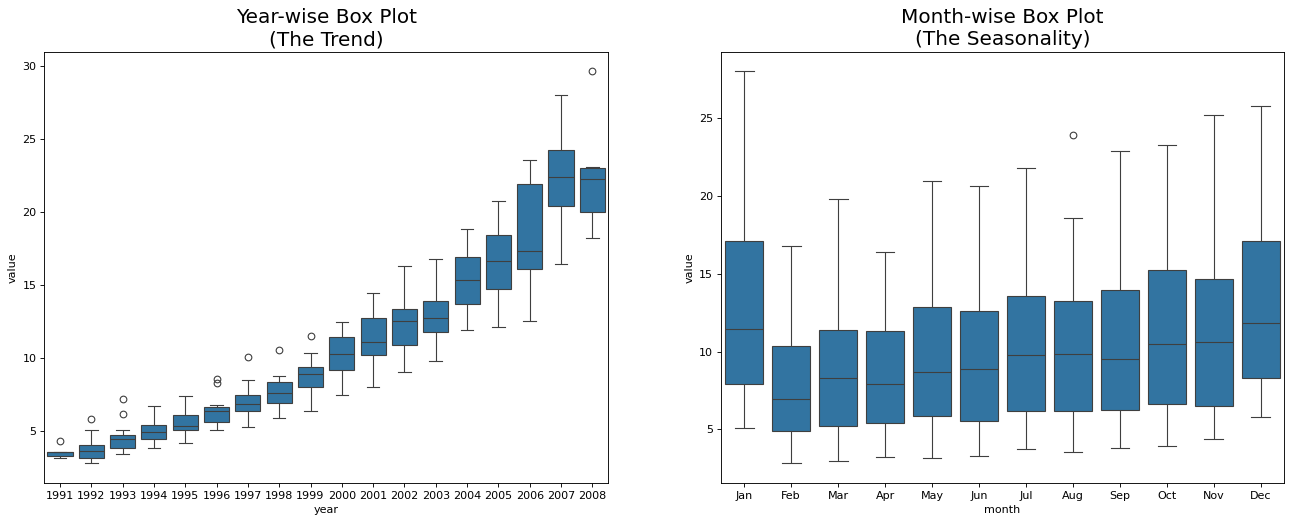

In [33]:
# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)
sns.boxplot(x='year', y='value', data=df, ax=axes[0])
sns.boxplot(x='month', y='value', data=df.loc[~df.year.isin([1991, 2008]), :])

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18);
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

Variabilidade nos anos não é constante.
Média não é constante ao longo dos meses.

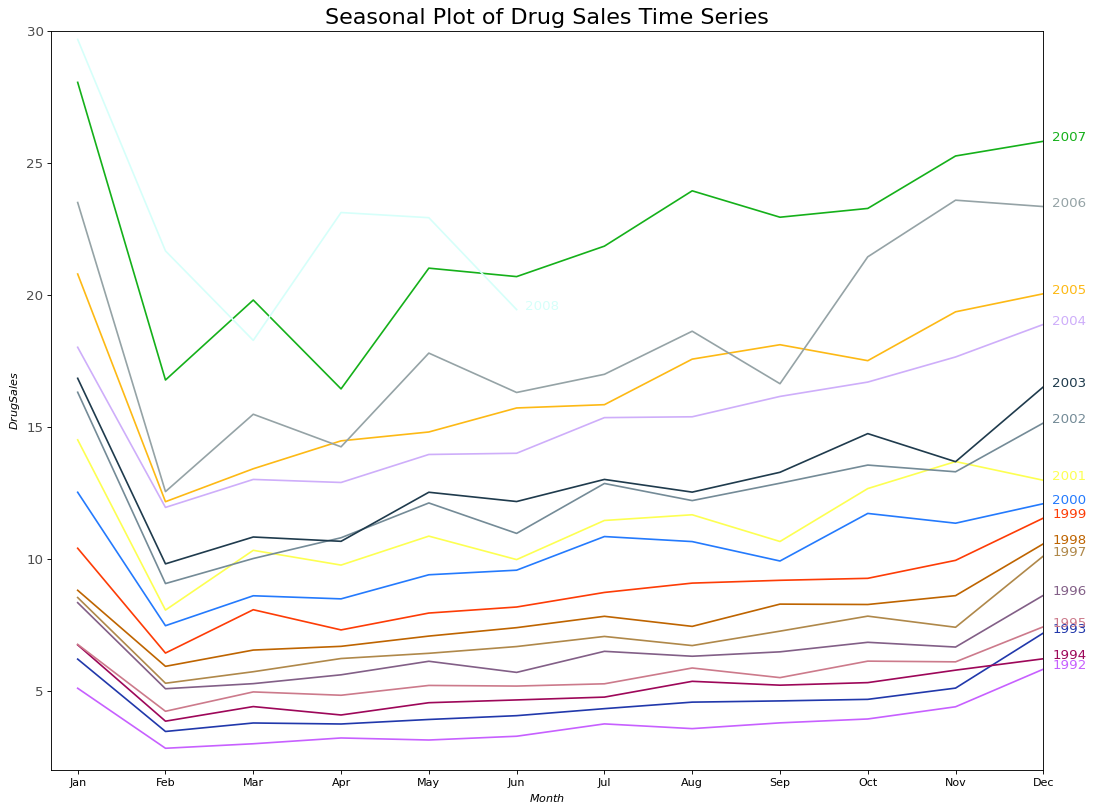

In [34]:
################################################################
#2. Verificando se há presença de sazonalidade
################################################################

# Prep Colors
np.random.seed(100)
mycolors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# Draw Plot
plt.figure(figsize=(16,12), dpi= 80)
for i, y in enumerate(years):
    if i > 0:
        plt.plot('month', 'value', data=df.loc[df.year==y, :], color=mycolors[i], label=y)
        plt.text(df.loc[df.year==y, :].shape[0]-.9, df.loc[df.year==y, 'value'][-1:].values[0], y, fontsize=12, color=mycolors[i])

# Decoration
plt.gca().set(xlim=(-0.3, 11), ylim=(2, 30), ylabel='$Drug Sales$', xlabel='$Month$')
plt.yticks(fontsize=12, alpha=.7)
plt.title("Seasonal Plot of Drug Sales Time Series", fontsize=20)
plt.show()

In [35]:
df['value']

,value
0,3.526591
1,3.180891
2,3.252221
3,3.611003
4,3.565869
...,...
199,21.654285
200,18.264945
201,23.107677
202,22.912510


## **DECOMPOSIÇÃO DA SÉRIE:**

ADITIVA E MULTIPLICATIVA

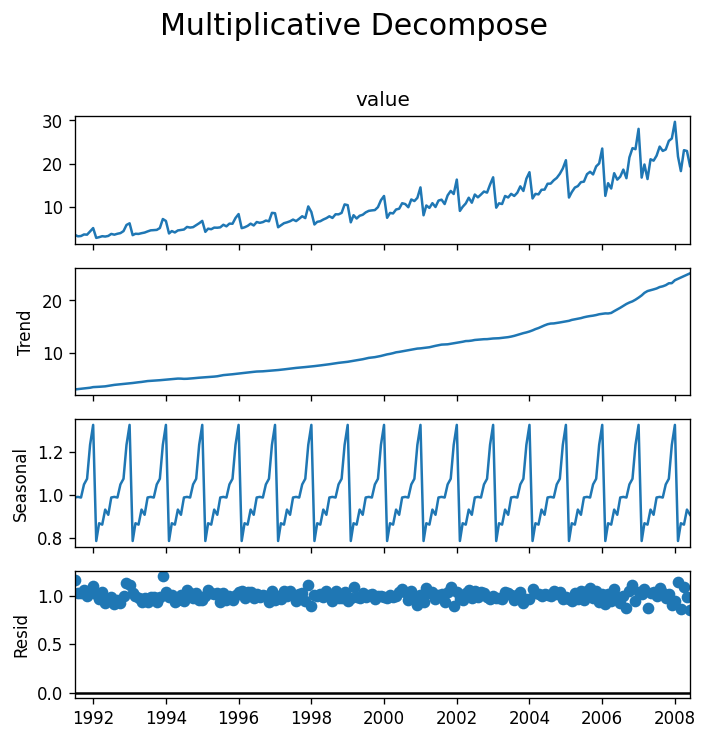

In [39]:
################################################################
#3. Fazendo a decomposição dos elementos da série
################################################################

df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv', parse_dates=['date'], index_col='date')

# Multiplicative Decomposition
result_mul = seasonal_decompose(df['value'], model='multiplicative', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (6,6)})
result_mul.plot().suptitle('Multiplicative Decompose', fontsize=18, y=1.02)

plt.tight_layout()
plt.show()

A decomposição aditiva é utilizada quando a sazonalidade mantém aproximadamente a mesma intensidade ao longo do tempo, enquanto a decomposição multiplicativa é mais adequada quando as oscilações sazonais aumentam ou diminuem conforme a série cresce.

Como a série A10 apresenta picos cada vez maiores ao longo do período analisado, o modelo multiplicativo é o mais indicado.

O primeiro gráfico é a série original.

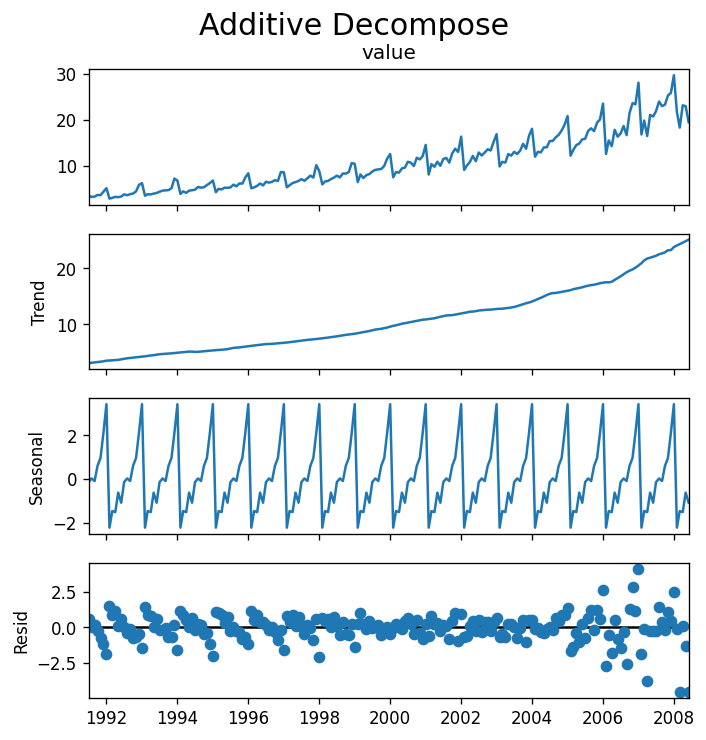

In [41]:
################################################################
#3. Fazendo a decomposição dos elementos da série
################################################################

# Additive Decomposition
result_add = seasonal_decompose(df['value'], model='additive', extrapolate_trend='freq')

# Plot
plt.rcParams.update({'figure.figsize': (6,6)})
result_add.plot().suptitle('Additive Decompose', fontsize=18, y=1.02)
plt.show()

## **AUTORRELAÇÃO:**

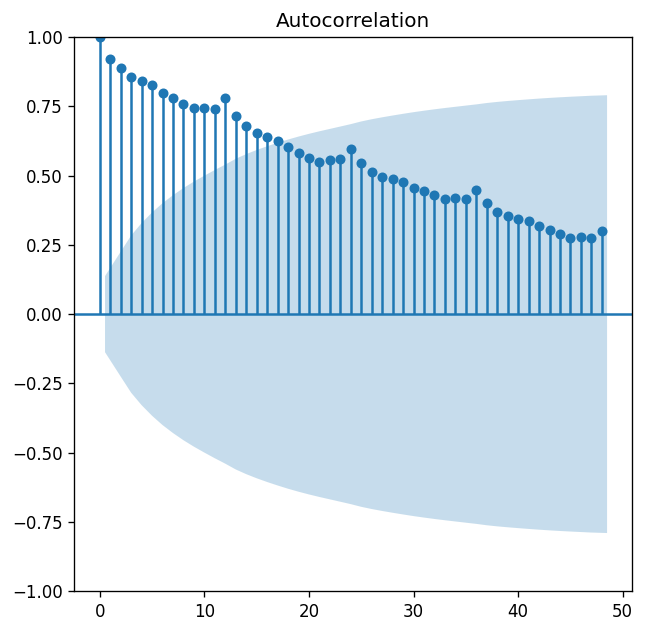

In [43]:
################################
#4. Verificando autocorrelação
################################
# Usando função ACF
plt.rcParams.update({'figure.figsize': (6,6)})
fig=sm.graphics.tsa.plot_acf(df.value,lags=48)

Aqui dá pra perceber a sazonalidade a cada 12 meses.

## **RUÍDO BRANCO:**

In [46]:
################################################################
#5. Verificando se a série é um Ruído Branco
################################################################

#5.1 Usando Teste Ljung-Box
#import statsmodels.api as sm
sm.stats.acorr_ljungbox(df.value, lags=[5], return_df=True)
#p_valor < nível_significancia  => rejeitar a hipotese nula => série não é ruído branco

,lb_stat,lb_pvalue
5,784.110251,3.167141e-167


In [47]:
#5.2 Outra função da mesma biblioteca, mas nesse caso temos o p-valor para cada lag
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(df['value'], lags=10)

print('P-values are:')
print(lb_test['lb_pvalue'])

P-values are:
1      4.813705e-40
2      1.978826e-74
3     2.787243e-106
4     2.939213e-137
5     3.167141e-167
6     3.419747e-195
7     4.383473e-222
8     1.075302e-247
9     2.599520e-272
10    3.450320e-297
Name: lb_pvalue, dtype: float64
